<a href="https://colab.research.google.com/github/kxilll/BSC_DPDM2025/blob/main/Ch5_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data

In [1]:
from sklearn.datasets import load_digits
digits = load_digits()
x, y = digits.data, digits.target
print(x.shape, y.shape)
print(len(digits.target_names))
print(y[:5])

(1797, 64) (1797,)
10
[0 1 2 3 4]


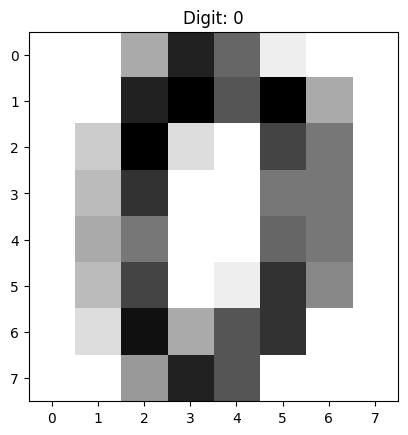

In [ ]:
import matplotlib.pyplot as plt
first_image = x[0]
first_label = y[0]

image_reshaped = first_image.reshape((8, 8))

plt.imshow(image_reshaped, cmap=plt.cm.gray_r, interpolation='nearest')
plt.title(f"Digit: {first_label}")
plt.show()

In [ ]:
digits.data

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]])

In [ ]:
import pandas as pd

df = pd.DataFrame(digits.data)
df['target'] = digits.target
df.shape

(1797, 65)

In [ ]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [ ]:
X_train = x[:1700]
y_train = y[:1700]
X_test = x[1700:]
y_test = y[1700:]

#Model Construction
- import
- define (hyper-parameters)
- train(fitting)
- eveluate

##import

In [ ]:
from sklearn.tree import DecisionTreeClassifier


##define

In [ ]:
tree0 = DecisionTreeClassifier(random_state=6)

##trainning

In [ ]:
tree0.fit(X_train,y_train)

DecisionTreeClassifier(random_state=6)

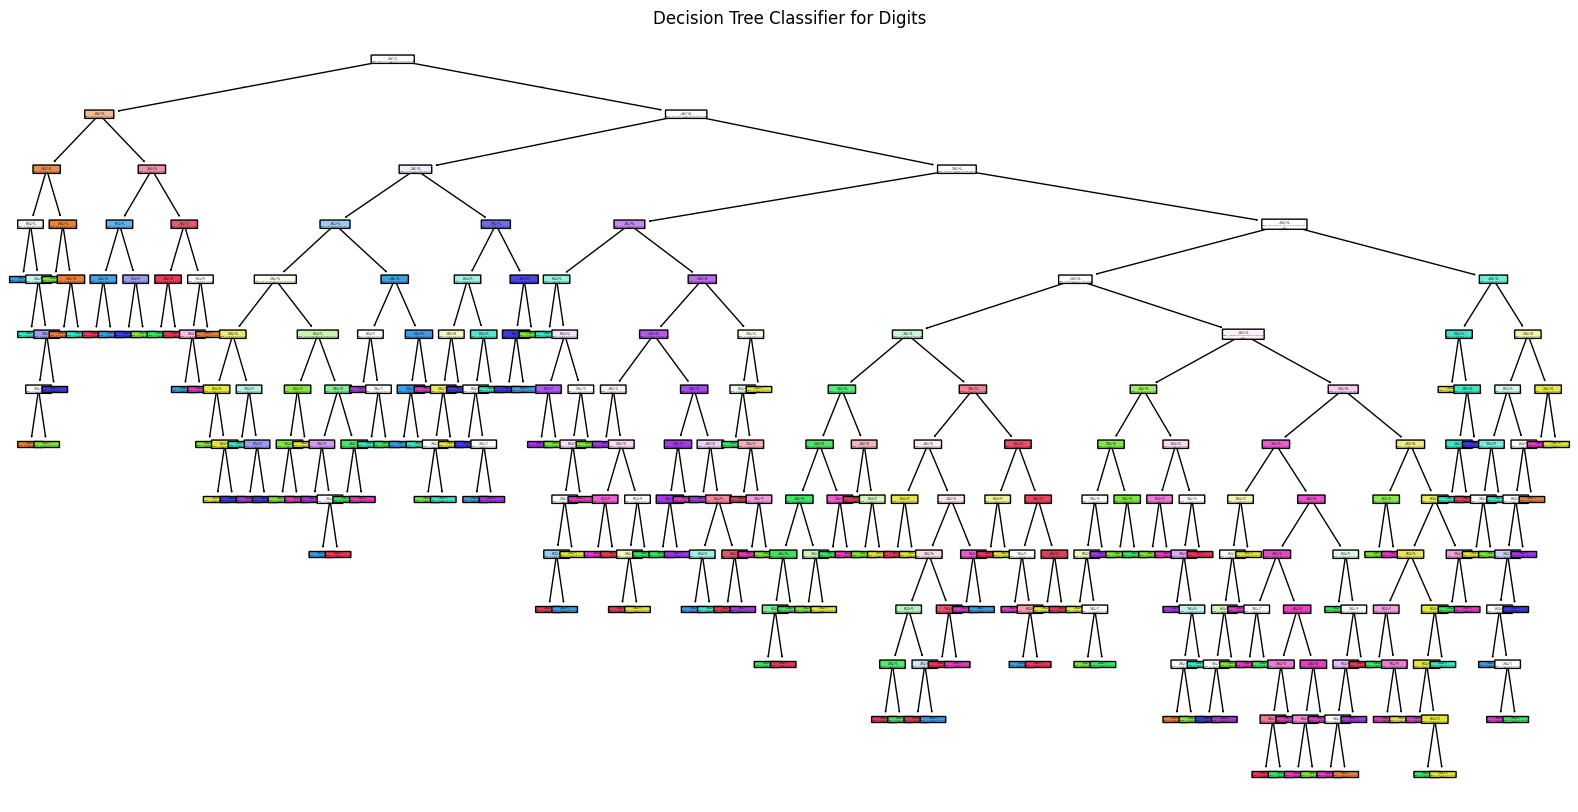

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(tree0, filled=True, rounded=True, feature_names=None, class_names=[str(i) for i in digits.target_names])
plt.title("Decision Tree Classifier for Digits")
plt.show()

##evaluate

In [ ]:
y_predict = tree0.predict(X_test)

In [ ]:
y_predict

array([8, 6, 5, 0, 9, 8, 9, 8, 4, 1, 7, 7, 9, 5, 1, 0, 0, 6, 2, 7, 8, 2,
       0, 3, 8, 6, 8, 8, 7, 4, 3, 4, 6, 6, 6, 4, 9, 1, 9, 0, 9, 6, 7, 8,
       2, 0, 0, 6, 7, 6, 8, 2, 1, 7, 4, 6, 3, 1, 2, 9, 1, 7, 6, 8, 4, 8,
       1, 4, 0, 5, 5, 6, 9, 6, 1, 7, 5, 4, 4, 7, 2, 5, 2, 2, 5, 7, 9, 4,
       4, 3, 3, 4, 9, 0, 8, 9, 8])

In [ ]:
y_test

array([5, 6, 5, 0, 9, 8, 9, 8, 4, 1, 7, 7, 3, 5, 1, 0, 0, 2, 2, 7, 8, 2,
       0, 1, 2, 6, 3, 3, 7, 3, 3, 4, 6, 6, 6, 4, 9, 1, 5, 0, 9, 5, 2, 8,
       2, 0, 0, 1, 7, 6, 3, 2, 1, 7, 4, 6, 3, 1, 3, 9, 1, 7, 6, 8, 4, 3,
       1, 4, 0, 5, 3, 6, 9, 6, 1, 7, 5, 4, 4, 7, 2, 8, 2, 2, 5, 7, 9, 5,
       4, 8, 8, 4, 9, 0, 8, 9, 8])

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_predict)

0.7938144329896907

##Pre-pruning {hyper-parameter tuning}

In [ ]:
from sklearn.tree import DecisionTreeClassifier #import
tree1 = DecisionTreeClassifier(random_state=6, max_depth=3) #define
tree1.fit(X_train,y_train) #train

DecisionTreeClassifier(max_depth=3, random_state=6)

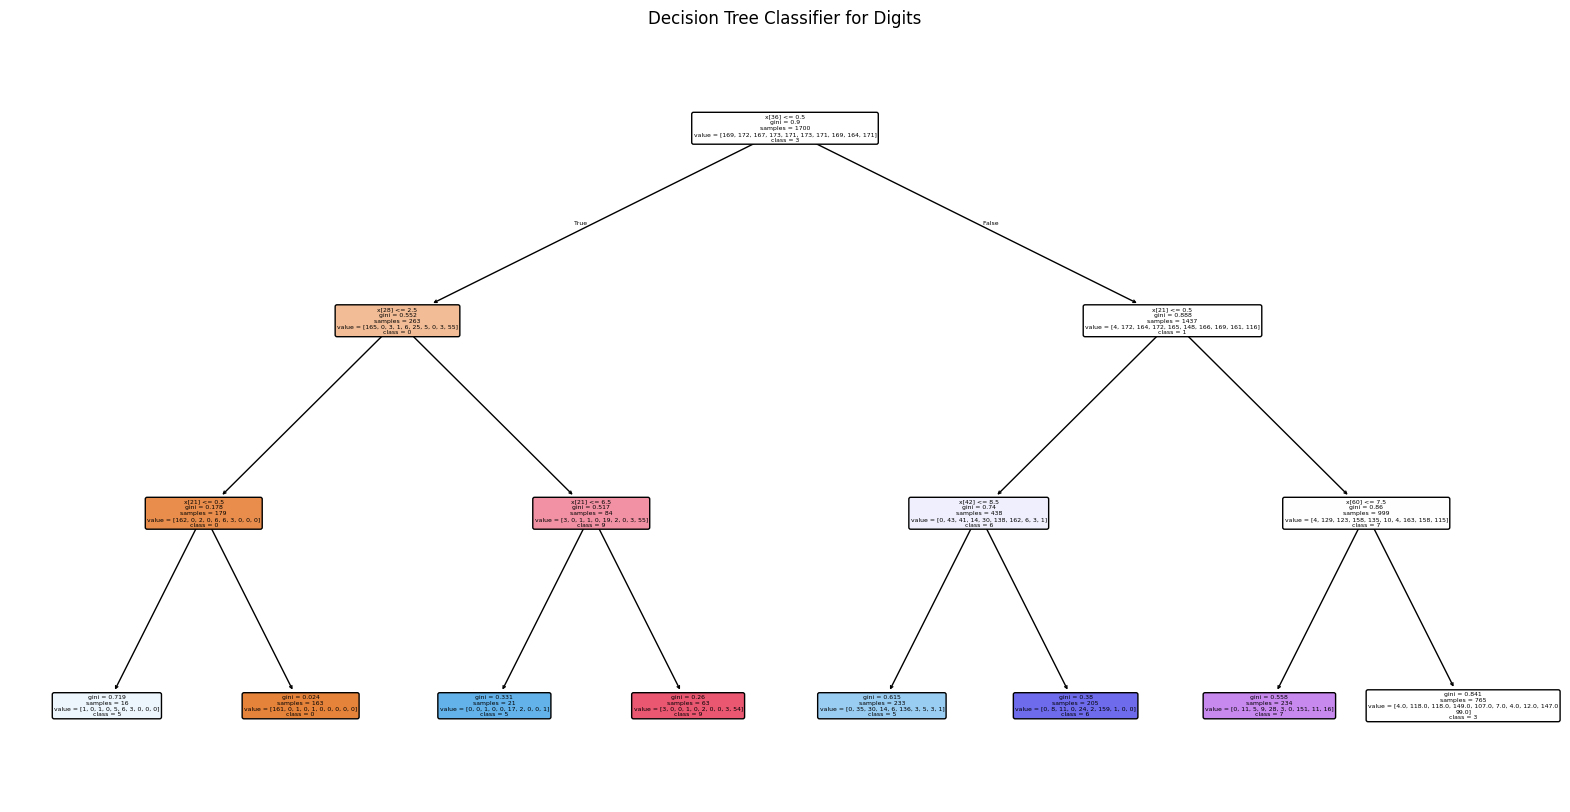

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(tree1, filled=True, rounded=True, feature_names=None, class_names=[str(i) for i in digits.target_names])
plt.title("Decision Tree Classifier for Digits")
plt.show()

In [ ]:
y_predict1 = tree1.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_predict1)

0.4639175257731959

## Tree2

In [ ]:
from sklearn.tree import DecisionTreeClassifier #import
tree2 = DecisionTreeClassifier(random_state=6, max_depth=7) #define
tree2.fit(X_train,y_train) #train
y_predict2 = tree2.predict(X_test)
accuracy_score(y_test, y_predict2)

0.7938144329896907

##Tree Quiz11

In [ ]:
from sklearn.tree import DecisionTreeClassifier #import
treeq = DecisionTreeClassifier(random_state=6,
    max_depth=None,
    min_samples_leaf=5,
    max_features='sqrt',
    ) #define
treeq.fit(X_train,y_train) #train
y_predictq = treeq.predict(X_test)
accuracy_score(y_test, y_predictq)

0.8144329896907216